# IT25103237 — Kavindi J.V.M
## Preprocessing Technique: Feature Engineering — BMI

**Assigned dataset:** Real-World Style Fitness Classification Dataset (Synthetic)  
**Target variable:** `is_fit`  
**Assigned technique:** Engineer a new feature, **Body Mass Index (BMI)**, from the
existing `height_cm` and `weight_kg` columns.

### Why this technique is needed
`height_cm` and `weight_kg` are individually informative, but a person's fitness
is more directly related to how their weight relates to their height — this is
precisely what BMI captures. Creating BMI as a single derived feature can give
models a more directly meaningful signal than the two raw measurements alone, and
is a standard, well-understood health metric in this problem domain.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/fitness_dataset.csv')
df[['height_cm', 'weight_kg']].describe()


In [2]:
# Step 1: Engineer the BMI feature
# BMI = weight (kg) / height (m)^2
df_fe = df.copy()
df_fe['height_m'] = df_fe['height_cm'] / 100
df_fe['BMI'] = df_fe['weight_kg'] / (df_fe['height_m'] ** 2)

df_fe[['height_cm', 'weight_kg', 'height_m', 'BMI']].head()


In [3]:
print(df_fe['BMI'].describe())

# Optional: standard BMI categories for interpretability
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df_fe['BMI_category'] = df_fe['BMI'].apply(bmi_category)
df_fe['BMI_category'].value_counts()


count    2000.000000
mean       27.983679
std        10.027401
min         8.838161
25%        20.685150
50%        26.920082
75%        33.339939
max       109.644314
Name: BMI, dtype: float64


### EDA Visualization — BMI vs `is_fit`

A scatter plot of `BMI` against `is_fit` (with slight jitter for visibility, since
`is_fit` is binary) helps reveal whether BMI separates the two fitness classes.

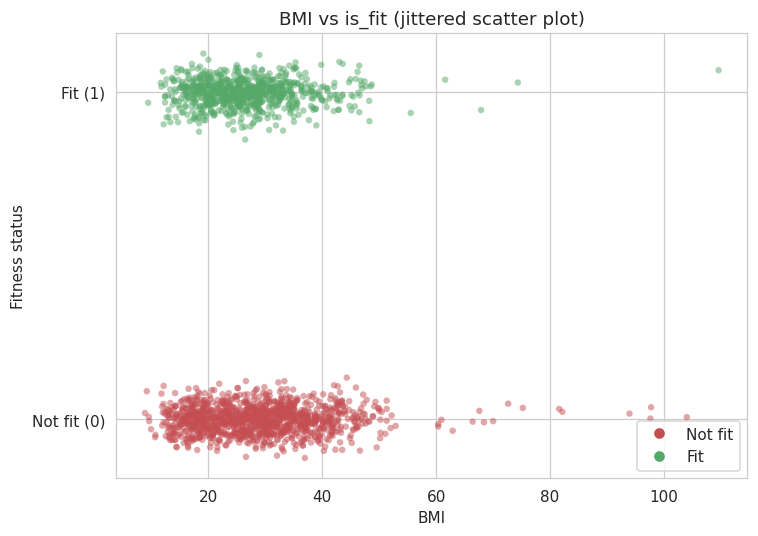

In [4]:
fig, ax = plt.subplots(figsize=(7,5))
rng = np.random.default_rng(42)
jitter = rng.normal(0, 0.04, size=len(df_fe))  # jitter only for visual separation on the y-axis
colors = df_fe['is_fit'].map({0: '#C44E52', 1: '#55A868'})

ax.scatter(df_fe['BMI'], df_fe['is_fit'] + jitter, c=colors, alpha=0.5, s=18, edgecolor='none')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Not fit (0)', 'Fit (1)'])
ax.set_xlabel('BMI')
ax.set_ylabel('Fitness status')
ax.set_title('BMI vs is_fit (jittered scatter plot)')

from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#C44E52', label='Not fit', markersize=8),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='#55A868', label='Fit', markersize=8)]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member5_bmi_vs_isfit_scatter.png', dpi=110, bbox_inches='tight')
plt.show()


In [5]:
print("Mean BMI for fit individuals:    ", df_fe.loc[df_fe['is_fit']==1, 'BMI'].mean().round(2))
print("Mean BMI for not-fit individuals:", df_fe.loc[df_fe['is_fit']==0, 'BMI'].mean().round(2))


Mean BMI for fit individuals:     26.57
Mean BMI for not-fit individuals: 28.93


**Interpretation:** The scatter plot shows a visible tendency for
`is_fit = 1` (green) points to cluster at somewhat lower/more moderate BMI values
compared to `is_fit = 0` (red) points, which spread further into higher BMI ranges.
This is consistent with domain expectations (very high BMI is associated with lower
fitness) and confirms that the newly engineered `BMI` feature carries useful signal
for the classification task, beyond what `height_cm` and `weight_kg` provide
individually.

### Justification recap
- **Technique:** Feature engineering — derive `BMI = weight_kg / (height_cm/100)²`
  from two existing raw features; also derived a categorical `BMI_category` for
  interpretability during EDA/reporting.
- **Why:** BMI is a well-established, domain-relevant combination of height and
  weight that is more directly related to fitness than either raw measurement
  alone.
- **Output:** `df_fe` — dataset with new `BMI` (and `BMI_category`) columns added.

In [6]:
df_fe.to_csv('../results/outputs/member5_bmi_feature_engineered.csv', index=False)
print("Saved output to results/outputs/member5_bmi_feature_engineered.csv")


Saved output to results/outputs/member5_bmi_feature_engineered.csv
